# Notebook 2 — Feature Engineering & Social Prescription Recommendation (Age ≥ 65)

This notebook loads the baseline analytic dataset produced by Notebook 1 and builds:
1) an interpretable risk score,
2) a transparent rule-based recommendation engine (social prescription),
3) coverage checks (overall + subgroups).

**Input from Notebook 1**
- `../data_processed/notebook1_baseline_analytic.csv`

**Outputs from this notebook**
- `../data_processed/notebook2_recommendations.csv`
- `../data_processed/notebook2_coverage_report.csv`
- `../data_processed/notebook2_missingness_report.csv`
- plots for risk score distribution and recommendation coverage

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data_processed"

INFILE = os.path.join(DATA_DIR, "notebook1_baseline_analytic.csv")

OUT_RECO = os.path.join(DATA_DIR, "notebook2_recommendations.csv")
OUT_COVERAGE = os.path.join(DATA_DIR, "notebook2_coverage_report.csv")
OUT_MISSINGNESS = os.path.join(DATA_DIR, "notebook2_missingness_report.csv")

print("CWD:", os.getcwd())
print("INFILE:", INFILE)
print("Exists:", os.path.exists(INFILE))

CWD: c:\Users\Yu\Desktop\BMI5111_Capstone_YuJun\notebooks
INFILE: ../data_processed\notebook1_baseline_analytic.csv
Exists: True


In [2]:
df = pd.read_csv(INFILE)
print("Loaded:", df.shape)
df.head()

Loaded: (29371, 10)


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
0,2010,5,65.0,2,1.0,0.0,0.0,1.0,0.0,0
1,3010,11,76.0,1,3.0,0.0,0.0,0.0,1.0,0
2,3020,12,75.0,2,5.0,0.0,0.0,0.0,1.0,0
3,10001010,16,83.0,1,3.0,0.0,0.0,1.0,0.0,0
4,10003030,16,66.0,2,5.0,0.0,0.0,2.0,0.0,0


In [3]:
print(df.columns.tolist())
df.describe(include="all").T.head(20)

['hhidpn', 'wave', 'age', 'gender', 'edu_years', 'diabetes', 'adl_any', 'cesd', 'hosp', 'high_risk']


,count,mean,std,min,25%,50%,75%,max
hhidpn,29371.0,2.230764e+08,2.148915e+08,2010.0,58515515.0,201890010.0,211351015.0,959738010.0
wave,29371.0,1.116891e+01,4.689120e+00,1.0,7.0,12.0,16.0,16.0
age,29371.0,7.838814e+01,8.577403e+00,65.0,71.0,78.0,85.0,109.0
gender,29371.0,1.562460e+00,4.960919e-01,1.0,1.0,2.0,2.0,2.0
edu_years,29362.0,2.951706e+00,1.454433e+00,1.0,1.0,3.0,4.0,5.0
diabetes,29299.0,3.232875e-01,5.993893e-01,0.0,0.0,0.0,1.0,6.0
adl_any,29322.0,3.725530e-01,4.834928e-01,0.0,0.0,0.0,1.0,1.0
cesd,23887.0,1.766693e+00,2.081010e+00,0.0,0.0,1.0,3.0,8.0
hosp,29042.0,4.079265e-01,4.914578e-01,0.0,0.0,0.0,1.0,1.0
high_risk,29371.0,5.895611e-01,4.919218e-01,0.0,0.0,1.0,1.0,1.0


## 1) Basic cleaning / type fixes

We keep the dataset as-is (already baseline analytic from Notebook 1), and only do minimal safety conversions.

In [4]:
data = df.copy()

# Strip column names
data.columns = [c.strip() for c in data.columns]

# Convert obvious numeric columns to numeric when possible
for c in data.columns:
    if data[c].dtype == "object":
        # try numeric conversion; if too many become NaN, keep as object
        tmp = pd.to_numeric(data[c], errors="coerce")
        # if at least 70% convertible, replace
        if tmp.notna().mean() >= 0.7:
            data[c] = tmp

print(data.dtypes)
data.head()

hhidpn         int64
wave           int64
age          float64
gender         int64
edu_years    float64
diabetes     float64
adl_any      float64
cesd         float64
hosp         float64
high_risk      int64
dtype: object


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
0,2010,5,65.0,2,1.0,0.0,0.0,1.0,0.0,0
1,3010,11,76.0,1,3.0,0.0,0.0,0.0,1.0,0
2,3020,12,75.0,2,5.0,0.0,0.0,0.0,1.0,0
3,10001010,16,83.0,1,3.0,0.0,0.0,1.0,0.0,0
4,10003030,16,66.0,2,5.0,0.0,0.0,2.0,0.0,0


## 2) Identify key columns

Notebook 1 output seems to contain variables like:
- hosp, next_hosp, high_risk

We will:
- infer ID column (if exists)
- infer age column (if exists) and apply Age ≥ 65 filter if age is present
- build risk_score from available predictors (fallback strategy if some columns are missing)

In [5]:
def pick_first_existing_col(df, candidates, required=False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the candidate columns exist: {candidates}")
    return None

id_col = pick_first_existing_col(data, ["hhidpn", "HHIDPN", "id", "ID", "person_id"], required=False)
age_col = pick_first_existing_col(data, ["age", "AGE", "r_age", "baseline_age"], required=False)
sex_col = pick_first_existing_col(data, ["female", "sex", "SEX", "gender"], required=False)

print("id_col:", id_col)
print("age_col:", age_col)
print("sex_col:", sex_col)

# If age exists, enforce Age ≥ 65 (instructor requirement)
if age_col is not None:
    data[age_col] = pd.to_numeric(data[age_col], errors="coerce")
    before = data.shape[0]
    data = data[data[age_col] >= 65].copy()
    after = data.shape[0]
    print(f"Applied age>=65 filter: {before} -> {after}")
else:
    print("No age column found; skip age>=65 filter (dataset may already be restricted).")

data.head()

id_col: hhidpn
age_col: age
sex_col: gender
Applied age>=65 filter: 29371 -> 29371


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
0,2010,5,65.0,2,1.0,0.0,0.0,1.0,0.0,0
1,3010,11,76.0,1,3.0,0.0,0.0,0.0,1.0,0
2,3020,12,75.0,2,5.0,0.0,0.0,0.0,1.0,0
3,10001010,16,83.0,1,3.0,0.0,0.0,1.0,0.0,0
4,10003030,16,66.0,2,5.0,0.0,0.0,2.0,0.0,0


## 3) Coverage report

We quantify missingness of each column (basic transparency).

In [6]:
coverage_df = pd.DataFrame({
    "column": data.columns,
    "missing_rate": [float(data[c].isna().mean()) for c in data.columns],
    "dtype": [str(data[c].dtype) for c in data.columns]
}).sort_values("missing_rate", ascending=False)

coverage_df.to_csv(OUT_MISSINGNESS, index=False)
coverage_df.head(30)

,column,missing_rate,dtype
7,cesd,0.186715,float64
8,hosp,0.011202,float64
5,diabetes,0.002451,float64
6,adl_any,0.001668,float64
4,edu_years,0.000306,float64
0,hhidpn,0.000000,int64
1,wave,0.000000,int64
3,gender,0.000000,int64
2,age,0.000000,float64
9,high_risk,0.000000,int64


## 4) Risk score (interpretable, rule-based)

We construct a simple, transparent risk score using 6 interpretable risk indicators:

| Indicator | Threshold | Rationale/Source |
|-----------|-----------|------------------|
| hosp_ge1 | Any hospitalization in past 2 years | Prior hospitalization is the strongest predictor of readmission |
| cesd_ge4 | CESD ≥ 4 | 8-item CESD threshold for clinically significant depressive symptoms |
| adl_any_eq1 | Any ADL difficulty | Functional limitation increases risk of adverse outcomes |
| diabetes_eq1 | Has diabetes | Chronic disease management needs indicator |
| age_ge80 | Age ≥ 80 | Advanced age as proxy for frailty |
| edu_le12 | Education years ≤ 12 | Low education as proxy for socioeconomic vulnerability |

Each indicator contributes 1 point. Final `risk_score` = (score) / (total indicators), ranging from 0-1.

This count-based approach prioritizes **interpretability** over predictive accuracy, aligning with the project requirement for transparent, rule-based logic.

In [7]:
import numpy as np
import pandas as pd

# ---------- Risk score (transparent count-based, auto-expand) ----------
risk_items = {}

def col_exists(c):
    return c in data.columns

def to_num(s, fill=None):
    x = pd.to_numeric(s, errors="coerce")
    if fill is not None:
        x = x.fillna(fill)
    return x

# 1) Prior hospital utilisation: hosp >= 1
if col_exists("hosp"):
    risk_items["hosp_ge1"] = (to_num(data["hosp"], fill=0) >= 1).astype(int)

# 2) Elevated depressive symptoms proxy: CESD >= 4
# (your column name is "cesd" in Notebook1 output)
if col_exists("cesd"):
    risk_items["cesd_ge4"] = (to_num(data["cesd"]) >= 4).astype(int)

# 3) Functional limitation: ADL any difficulty == 1
# (your Notebook1 mentioned "adl_any")
if col_exists("adl_any"):
    risk_items["adl_any_eq1"] = (to_num(data["adl_any"], fill=0) >= 1).astype(int)

# 4) Chronic condition: diabetes == 1
if col_exists("diabetes"):
    risk_items["diabetes_eq1"] = (to_num(data["diabetes"], fill=0) >= 1).astype(int)

# 5) Older age band: age >= 80 (optional but interpretable)
# use inferred age_col if you already detected it; otherwise try common names
age_candidate = None
for c in ["age", "AGE", "r_age", "baseline_age", "age_years"]:
    if c in data.columns:
        age_candidate = c
        break

if age_candidate is not None:
    risk_items["age_ge80"] = (to_num(data[age_candidate]) >= 80).astype(int)

# 6) Low education: edu_years <= 12 (optional socioeconomic vulnerability proxy)
# (your Notebook1 showed "edu_years")
if col_exists("edu_years"):
    edu = to_num(data["edu_years"])
    risk_items["edu_le12"] = ((edu.notna()) & (edu <= 12)).astype(int)

risk_df = pd.DataFrame(risk_items)

if risk_df.shape[1] == 0:
    data["risk_score"] = np.nan
    print("WARNING: No risk features available to compute risk_score.")
else:
    # proportion in [0,1], robust to missing columns
    data["risk_score"] = risk_df.sum(axis=1) / risk_df.shape[1]
    print("Risk features used:", list(risk_df.columns))
    print("risk_score summary:\n", data["risk_score"].describe())

    # Optional: show how many triggered per item (quick transparency)
    item_rates = risk_df.mean().sort_values(ascending=False)
    print("Risk item positive rates:\n", item_rates)

# ---------- High-risk flag (keep Notebook1 definition if present) ----------
if "high_risk" in data.columns:
    data["high_risk"] = pd.to_numeric(data["high_risk"], errors="coerce").fillna(0).astype(int)
    print("Using existing high_risk from Notebook 1 (cleaned to 0/1).")
else:
    if data["risk_score"].notna().any():
        thr = data["risk_score"].quantile(0.80)
        data["high_risk_fallback"] = (data["risk_score"] >= thr).astype(int)
        print(f"high_risk not found. Created high_risk_fallback using risk_score >= {thr:.3f} (top 20%).")
    else:
        data["high_risk_fallback"] = 0
        print("high_risk not found and risk_score unavailable. Created high_risk_fallback=0 for all.")

Risk features used: ['hosp_ge1', 'cesd_ge4', 'adl_any_eq1', 'diabetes_eq1', 'age_ge80', 'edu_le12']
risk_score summary:
 count    29371.000000
mean         0.445002
std          0.202810
min          0.000000
25%          0.333333
50%          0.500000
75%          0.666667
max          1.000000
Name: risk_score, dtype: float64
Risk item positive rates:
 edu_le12        0.999694
age_ge80        0.447448
hosp_ge1        0.403357
adl_any_eq1     0.371931
diabetes_eq1    0.292942
cesd_ge4        0.154642
dtype: float64
Using existing high_risk from Notebook 1 (cleaned to 0/1).


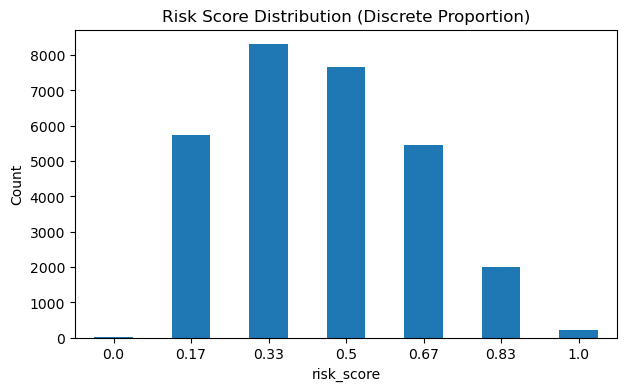

In [8]:
# Plot 1 — Risk score distribution (clean x-axis)

if "risk_score" in data.columns and data["risk_score"].notna().any():
    
    # Round to 2 decimal places for clean labels
    rounded_score = data["risk_score"].round(2)
    vc = rounded_score.value_counts().sort_index()

    plt.figure(figsize=(7,4))
    vc.plot(kind="bar")
    plt.title("Risk Score Distribution (Discrete Proportion)")
    plt.xlabel("risk_score")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

else:
    print("No valid risk_score available to plot.")

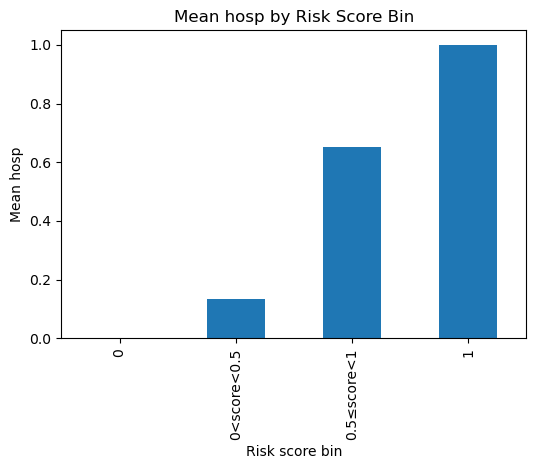

In [9]:
# Plot 2 — Outcome by risk level (sanity check)
outcome_col = None
for c in ["next_hosp", "hosp"]:
    if c in data.columns:
        outcome_col = c
        break

if outcome_col is None:
    print("No hosp/next_hosp column found for sanity check plot.")
else:
    tmp_out = pd.to_numeric(data[outcome_col], errors="coerce")
    tmp_risk = data["risk_score"] if "risk_score" in data.columns else None
    
    if tmp_risk is not None and tmp_risk.notna().any():
        # simple binning for interpretability
        bins = [-0.01, 0.01, 0.49, 0.99, 1.01]
        labels = ["0", "0<score<0.5", "0.5≤score<1", "1"]
        risk_bin = pd.cut(tmp_risk, bins=bins, labels=labels)
        
        plot_df = pd.DataFrame({"risk_bin": risk_bin, "outcome": tmp_out}).dropna()
        means = plot_df.groupby("risk_bin")["outcome"].mean()
        
        plt.figure(figsize=(6,4))
        means.plot(kind="bar")
        plt.title(f"Mean {outcome_col} by Risk Score Bin")
        plt.xlabel("Risk score bin")
        plt.ylabel(f"Mean {outcome_col}")
        plt.show()
    else:
        print("risk_score not available for sanity check plot.")

## 5) Recommendation engine (rule-based + reason codes)

We generate top-3 social prescription recommendations.
Rules adapt to available columns; if a signal is missing, that rule is skipped.

Output fields:
- top1, top2, top3
- reasons (joined)
- n_recs
- has_reco

## Service Catalogue (Rule-based Mapping)

This notebook outputs **service category recommendations** using **transparent, rule-based logic**.

| HRS Feature | Rule (threshold) | Need Domain | Service Category Recommended | Rationale |
|---|---|---|---|---|
| hosp | hosp ≥ 1 | care transitions | Care coordination / follow-up | Higher post-discharge needs & follow-up |
| cesd | CESD ≥ 4 | mental health | Mental health support | Elevated depressive symptoms proxy |
| high_risk (from Notebook 1) | high_risk == 1 | complex needs | Proactive outreach / case management | Higher complexity / multi-need |
| default | otherwise | general | General community resource information | Universal info; used to operationalise usual referral comparator |

**Comparator operationalisation:**  
We treat individuals who only receive **General community resource information** as **"usual referral / no social prescription"** (comparator group).  
Individuals who receive at least one **specific** service category are treated as **intervention-exposed**.

In [10]:
import pandas as pd

DEFAULT_SERVICE = "General community resource information"

RULES = [
    {
        "name": "Post-discharge / care transition needs",
        "priority": 1,
        "service": "Care coordination / follow-up",
        "cond": lambda r: ("hosp" in r and pd.notna(r["hosp"]) and float(r["hosp"]) >= 1),
    },
    {
        "name": "Elevated depressive symptoms (CESD proxy)",
        "priority": 2,
        "service": "Mental health support",
        "cond": lambda r: ("cesd" in r and pd.notna(r["cesd"]) and float(r["cesd"]) >= 4),
    },
    {
        "name": "High complexity / high-risk flag (from Notebook 1)",
        "priority": 3,
        "service": "Proactive outreach / case management",
        "cond": lambda r: ("high_risk" in r and pd.notna(r["high_risk"]) and int(r["high_risk"]) == 1),
    },
    {
        "name": "Functional limitation (ADL difficulty)",
        "priority": 2.5,
        "service": "Rehabilitation / functional support",
        "cond": lambda r: ("adl_any" in r and pd.notna(r["adl_any"]) and float(r["adl_any"]) >= 1),
    },
    {
        "name": "Chronic condition (diabetes)",
        "priority": 2.6,
        "service": "Chronic disease self-management support",
        "cond": lambda r: ("diabetes" in r and pd.notna(r["diabetes"]) and float(r["diabetes"]) >= 1),
    },
]

def recommend_row(row, topk=3):
    """
    Returns:
      services: list[str]  (sorted by priority)
      reasons:  list[str]  (human-readable rule names, aligned with services)
    """
    hits = []
    for rule in RULES:
        try:
            if rule["cond"](row):
                hits.append((rule["priority"], rule["service"], rule["name"]))
        except Exception:
            # Robust to unexpected row values
            continue

    hits.sort(key=lambda x: x[0])
    services = [h[1] for h in hits][:topk]
    reasons  = [h[2] for h in hits][:topk]

    if len(services) == 0:
        services = [DEFAULT_SERVICE]
        reasons  = ["Default / universal info (operationalises usual referral comparator)"]

    return services, reasons

# quick sanity print (so Cell 13 produces visible output)
print("Rules loaded:", len(RULES))
print("Default service:", DEFAULT_SERVICE)

Rules loaded: 5
Default service: General community resource information


In [11]:
import numpy as np
import pandas as pd

# Apply recommendation to each row
tmp = data.apply(lambda r: recommend_row(r, topk=3), axis=1)
data["reco_list"] = tmp.apply(lambda x: x[0])
data["reco_reason_list"] = tmp.apply(lambda x: x[1])

# Extract top1/top2/top3 (safe)
def get_k(lst, k):
    if isinstance(lst, list) and len(lst) > k:
        return lst[k]
    return None

data["top1"] = data["reco_list"].apply(lambda x: get_k(x, 0))
data["top2"] = data["reco_list"].apply(lambda x: get_k(x, 1))
data["top3"] = data["reco_list"].apply(lambda x: get_k(x, 2))

# Operationalise intervention vs comparator:
# - Only DEFAULT_SERVICE => comparator (usual referral / no social prescription)
# - Any specific service => intervention_exposed
data["has_specific_reco"] = (data["top1"] != DEFAULT_SERVICE).astype(int)
data["intervention_exposed"] = data["has_specific_reco"]
data["comparator_usual_referral"] = (1 - data["intervention_exposed"]).astype(int)

print("Any recommendation coverage:", float(data["top1"].notna().mean()))
print("Specific recommendation coverage (intervention_exposed=1):", float(data["intervention_exposed"].mean()))
print("Comparator coverage (usual referral):", float(data["comparator_usual_referral"].mean()))

# Quick preview
data[["top1","top2","top3","intervention_exposed","comparator_usual_referral"]].head(10)


Any recommendation coverage: 1.0
Specific recommendation coverage (intervention_exposed=1): 0.7036873106125089
Comparator coverage (usual referral): 0.29631268938749106


,top1,top2,top3,intervention_exposed,comparator_usual_referral
0,General community resource information,NaN,NaN,0,1
1,Care coordination / follow-up,NaN,NaN,1,0
2,Care coordination / follow-up,NaN,NaN,1,0
3,General community resource information,NaN,NaN,0,1
4,General community resource information,NaN,NaN,0,1
5,Care coordination / follow-up,NaN,NaN,1,0
6,General community resource information,NaN,NaN,0,1
7,Chronic disease self-management support,Proactive outreach / case management,NaN,1,0
8,Care coordination / follow-up,NaN,NaN,1,0
9,General community resource information,NaN,NaN,0,1


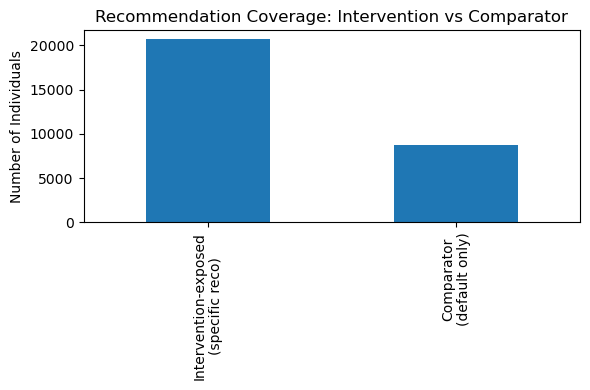

Saved figure: ../figures\nb2_recommendation_coverage_intervention_vs_comparator.png


In [12]:
# =========================
# Figure 3 — Recommendation coverage (intervention vs comparator)
# =========================

import os
import matplotlib.pyplot as plt
import pandas as pd

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)

if "intervention_exposed" in data.columns and "comparator_usual_referral" in data.columns:
    counts = pd.Series({
        "Intervention-exposed\n(specific reco)": int(data["intervention_exposed"].sum()),
        "Comparator\n(default only)": int(data["comparator_usual_referral"].sum()),
    })

    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.title("Recommendation Coverage: Intervention vs Comparator")
    plt.ylabel("Number of Individuals")
    plt.xlabel("")
    plt.tight_layout()

    OUT_FIG3 = os.path.join(FIG_DIR, "nb2_recommendation_coverage_intervention_vs_comparator.png")
    plt.savefig(OUT_FIG3, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved figure:", OUT_FIG3)

else:
    print("Coverage flags not found for plotting.")

## 6) Coverage checks (overall + subgroup)

We report:
- overall % with at least 1 recommendation (any coverage)
- overall % with at least 1 **specific** recommendation (intervention exposure)
- subgroup coverage by sex (if available) and by age bands (if age exists)


In [13]:
import pandas as pd
import numpy as np

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

gender_col = pick_col(data, ["gender", "sex", "ragender", "rsex"])
age_col    = pick_col(data, ["age", "r_agey", "agey", "raagey", "age_years"])

overall_any = float(data["top1"].notna().mean())
overall_specific = float(data["intervention_exposed"].mean())

print(f"Overall coverage (any recommendation): {overall_any:.3f}")
print(f"Overall coverage (specific / intervention_exposed): {overall_specific:.3f}")

coverage_rows = []
coverage_rows.append({
    "group": "ALL",
    "group_value": "ALL",
    "n": int(len(data)),
    "any_coverage": overall_any,
    "specific_coverage": overall_specific
})

if gender_col is not None:
    g = data.groupby(gender_col, dropna=False).agg(
        n=("top1", "size"),
        any_coverage=("top1", lambda s: float(s.notna().mean())),
        specific_coverage=("intervention_exposed", "mean"),
    ).reset_index().rename(columns={gender_col: "group_value"})
    g.insert(0, "group", "sex")
    coverage_rows += g.to_dict("records")

if age_col is not None:
    age_vals = pd.to_numeric(data[age_col], errors="coerce")
    age_band = pd.cut(age_vals, bins=[-np.inf, 49, 64, 74, 84, np.inf],
                      labels=["<=49","50-64","65-74","75-84","85+"])
    tmp_df = data.copy()
    tmp_df["_age_band"] = age_band

    a = tmp_df.groupby("_age_band", dropna=False).agg(
        n=("top1", "size"),
        any_coverage=("top1", lambda s: float(s.notna().mean())),
        specific_coverage=("intervention_exposed", "mean"),
    ).reset_index().rename(columns={"_age_band": "group_value"})
    a.insert(0, "group", "age_band")
    coverage_rows += a.to_dict("records")

coverage_report = pd.DataFrame(coverage_rows)
coverage_report


Overall coverage (any recommendation): 1.000
Overall coverage (specific / intervention_exposed): 0.704


,group,group_value,n,any_coverage,specific_coverage
0,ALL,ALL,29371,1.0,0.703687
1,sex,1,12851,1.0,0.692475
2,sex,2,16520,1.0,0.712409
3,age_band,65-74,10994,1.0,0.619520
4,age_band,75-84,10698,1.0,0.723126
5,age_band,85+,7679,1.0,0.797109


In [14]:
# =========================
# Table 2 for paper — Overall recommendation coverage
# Export to ../tables
# =========================

import os
import pandas as pd

TABLE_DIR = os.path.abspath("../tables")
os.makedirs(TABLE_DIR, exist_ok=True)

overall_table = pd.DataFrame([
    {
        "Group": "Intervention-exposed (specific recommendation)",
        "N": int(data["intervention_exposed"].sum()),
        "Percentage (%)": round(float(data["intervention_exposed"].mean() * 100), 1)
    },
    {
        "Group": "Comparator (usual referral)",
        "N": int(data["comparator_usual_referral"].sum()),
        "Percentage (%)": round(float(data["comparator_usual_referral"].mean() * 100), 1)
    },
    {
        "Group": "Total",
        "N": int(len(data)),
        "Percentage (%)": 100.0
    }
])

OUT_TABLE2 = os.path.join(TABLE_DIR, "table2_overall_recommendation_coverage.csv")
overall_table.to_csv(OUT_TABLE2, index=False)

print(overall_table)
print("Saved:", OUT_TABLE2)

                                            Group      N  Percentage (%)
0  Intervention-exposed (specific recommendation)  20668            70.4
1                     Comparator (usual referral)   8703            29.6
2                                           Total  29371           100.0
Saved: c:\Users\Yu\Desktop\BMI5111_Capstone_YuJun\tables\table2_overall_recommendation_coverage.csv


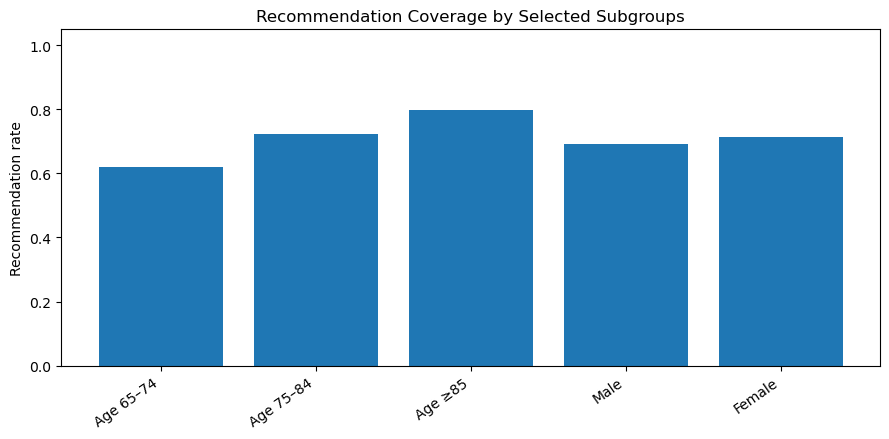

In [15]:
# Figure 4 — Recommendation coverage across selected subgroups
if "group" in coverage_report.columns and "specific_coverage" in coverage_report.columns:
    sub = coverage_report[coverage_report["group"] != "ALL"].copy()

    if len(sub) > 0:
        # Keep only the subgroups you want to show in the paper
        sub = sub[sub["group"].isin(["age_band", "sex", "adl_any"])].copy()

        # Remove age groups outside the study cohort (keep only age >= 65)
        sub = sub[~(
            (sub["group"] == "age_band") &
            (sub["group_value"].astype(str).isin(["<=49", "50-64"]))
        )].copy()

        # Create publication-friendly labels
        def pretty_label(row):
            g = str(row["group"])
            v = str(row["group_value"])

            if g == "age_band":
                age_map = {
                    "65-74": "Age 65–74",
                    "75-84": "Age 75–84",
                    "85+": "Age ≥85"
                }
                return age_map.get(v, v)

            if g == "sex":
                sex_map = {
                    "1": "Male",
                    "2": "Female",
                    "1.0": "Male",
                    "2.0": "Female"
                }
                return sex_map.get(v, f"Sex {v}")

            if g == "adl_any":
                adl_map = {
                    "0": "No ADL limitation",
                    "1": "Any ADL limitation",
                    "0.0": "No ADL limitation",
                    "1.0": "Any ADL limitation"
                }
                return adl_map.get(v, f"ADL {v}")

            return f"{g}: {v}"

        sub["plot_label"] = sub.apply(pretty_label, axis=1)

        # Optional: set display order
        label_order = [
            "Age 65–74",
            "Age 75–84",
            "Age ≥85",
            "Male",
            "Female",
            "No ADL limitation",
            "Any ADL limitation"
        ]
        sub["plot_label"] = pd.Categorical(sub["plot_label"], categories=label_order, ordered=True)
        sub = sub.sort_values("plot_label")

        plt.figure(figsize=(9, 4.5))
        plt.bar(sub["plot_label"].astype(str), sub["specific_coverage"])
        plt.title("Recommendation Coverage by Selected Subgroups")
        plt.ylabel("Recommendation rate")
        plt.xticks(rotation=35, ha="right")
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()

## 7) Save outputs

We save the recommendation outputs and coverage report for downstream evaluation.


In [16]:
# =========================
# Missingness report (Notebook2)
# =========================

import numpy as np
import pandas as pd

def missing_rate(s: pd.Series) -> float:
    return float(pd.isna(s).mean())

def to_num_safe(s: pd.Series) -> pd.Series:
    # handle strings like ".D" ".R" etc if any, convert to numeric where possible
    return pd.to_numeric(s.replace({r"^\.\w+$": np.nan}, regex=True), errors="coerce")

# Choose source table for missingness check
# - data: often contains recommendation outputs
# - df: baseline analytic
# We'll report BOTH, with a "source" column.
tables = []
if "df" in globals() and isinstance(df, pd.DataFrame):
    tables.append(("baseline_df", df.copy()))
if "data" in globals() and isinstance(data, pd.DataFrame):
    tables.append(("reco_data", data.copy()))

if not tables:
    raise ValueError("Cannot find df or data DataFrame in memory.")

# Candidate key columns to highlight (only keep those that exist)
key_candidates = [
    "hhidpn", "wave", "age", "gender", "edu_years",
    "diabetes", "adl_any", "cesd", "hosp",
    "risk_score", "high_risk",
    "top1", "top2", "top3",
    "reco_list", "reco_reason_list",
    "has_specific_reco", "intervention_exposed", "comparator_usual_referral",
    "next_hosp"
]

# Subgroups to check missingness by (only if present)
subgroup_candidates = ["gender", "age_band", "high_risk", "diabetes", "adl_any"]

all_reports = []

for source_name, T in tables:
    # Normalize column names to string
    T.columns = [str(c) for c in T.columns]

    # If age exists, create age_band (Age>=65 project)
    if "age" in T.columns:
        T["age"] = to_num_safe(T["age"])
        T["age_band"] = pd.cut(T["age"], bins=[65, 70, 75, 80, 85, 200], right=False)

    # 1) overall missingness for every column
    overall = pd.DataFrame({
        "source": source_name,
        "metric": "overall_missing_rate",
        "column": T.columns,
        "group": "ALL",
        "n": len(T),
        "missing_rate": [missing_rate(T[c]) for c in T.columns]
    })

    # 2) subgroup missingness for key columns only
    key_cols = [c for c in key_candidates if c in T.columns]
    subgroup_cols = [g for g in subgroup_candidates if g in T.columns]

    subgroup_rows = []
    for gcol in subgroup_cols:
        # drop groups that are all missing
        if T[gcol].isna().all():
            continue
        for kcol in key_cols:
            # compute missing rate within each group
            tmp = T.groupby(gcol, dropna=False)[kcol].apply(lambda x: pd.isna(x).mean())
            cnt = T.groupby(gcol, dropna=False)[kcol].size()

            for grp, mr in tmp.items():
                subgroup_rows.append({
                    "source": source_name,
                    "metric": "missing_rate_by_group",
                    "column": kcol,
                    "group_by": gcol,
                    "group": str(grp),
                    "n": int(cnt.loc[grp]),
                    "missing_rate": float(mr)
                })

    subgroup = pd.DataFrame(subgroup_rows)
    if subgroup.empty:
        subgroup = pd.DataFrame(columns=["source","metric","column","group_by","group","n","missing_rate"])

    # align schema
    overall2 = overall.rename(columns={"metric":"metric", "column":"column", "group":"group"})
    overall2["group_by"] = "ALL"
    overall2 = overall2[["source","metric","column","group_by","group","n","missing_rate"]]

    subgroup2 = subgroup[["source","metric","column","group_by","group","n","missing_rate"]]

    report = pd.concat([overall2, subgroup2], ignore_index=True)
    all_reports.append(report)

missingness_report = pd.concat(all_reports, ignore_index=True)

# Save
missingness_report.to_csv(OUT_MISSINGNESS, index=False)

print("Saved missingness report to:", OUT_MISSINGNESS)
print("Missingness report shape:", missingness_report.shape)
missingness_report.head(20)

Saved missingness report to: ../data_processed\notebook2_missingness_report.csv
Missingness report shape: (582, 7)


,source,metric,column,group_by,group,n,missing_rate
0,baseline_df,overall_missing_rate,hhidpn,ALL,ALL,29371,0.000000
1,baseline_df,overall_missing_rate,wave,ALL,ALL,29371,0.000000
2,baseline_df,overall_missing_rate,age,ALL,ALL,29371,0.000000
3,baseline_df,overall_missing_rate,gender,ALL,ALL,29371,0.000000
4,baseline_df,overall_missing_rate,edu_years,ALL,ALL,29371,0.000306
5,baseline_df,overall_missing_rate,diabetes,ALL,ALL,29371,0.002451
6,baseline_df,overall_missing_rate,adl_any,ALL,ALL,29371,0.001668
7,baseline_df,overall_missing_rate,cesd,ALL,ALL,29371,0.186715
8,baseline_df,overall_missing_rate,hosp,ALL,ALL,29371,0.011202
9,baseline_df,overall_missing_rate,high_risk,ALL,ALL,29371,0.000000


In [17]:
# =========================
# Export outputs (Notebook2) — FINAL STABLE VERSION
# =========================

ID_COL = "hhidpn"

# 1) Recommendations (start from `data`)
rec_df = data.copy()

# 如果 data 里没有 ID，就从 df 拼回
if ID_COL not in rec_df.columns:
    if ID_COL not in df.columns:
        raise ValueError(f"{ID_COL} not found in df.")
    if len(rec_df) != len(df):
        raise ValueError(
            f"Row mismatch: len(data)={len(rec_df)} != len(df)={len(df)}. "
            f"Cannot safely attach ID."
        )
    rec_df = pd.concat(
        [df[[ID_COL]].reset_index(drop=True),
         rec_df.reset_index(drop=True)],
        axis=1
    )

# 推荐相关列（只保留存在的）
reco_cols = [
    "risk_score",
    "high_risk",
    "high_risk_fallback",
    "top1", "top2", "top3",
    "reco_list", "reco_reason_list",
    "has_specific_reco",
    "intervention_exposed", "comparator_usual_referral"
]

reco_cols = [c for c in reco_cols if c in rec_df.columns]

final_cols = [ID_COL] + reco_cols

rec_df[final_cols].to_csv(OUT_RECO, index=False)

# 2) Coverage report
coverage_report.to_csv(OUT_COVERAGE, index=False)

# 3) Missingness report
missingness_report.to_csv(OUT_MISSINGNESS, index=False)

print("Saved recommendations to:", OUT_RECO)
print("Saved coverage report to:", OUT_COVERAGE)
print("Saved missingness report to:", OUT_MISSINGNESS)
print("Reco shape:", rec_df[final_cols].shape)
print("Reco cols:", final_cols)

Saved recommendations to: ../data_processed\notebook2_recommendations.csv
Saved coverage report to: ../data_processed\notebook2_coverage_report.csv
Saved missingness report to: ../data_processed\notebook2_missingness_report.csv
Reco shape: (29371, 11)
Reco cols: ['hhidpn', 'risk_score', 'high_risk', 'top1', 'top2', 'top3', 'reco_list', 'reco_reason_list', 'has_specific_reco', 'intervention_exposed', 'comparator_usual_referral']
